<a href="https://colab.research.google.com/github/obeabi/ProjectPortfolio/blob/master/SP500_Sector_Stages.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install --upgrade yfinance
!pip install  --upgrade pandas_ta
!pip install ta pandas_ta
!pip install scipy==1.16.2

  Using cached ta-0.11.0.tar.gz (25 kB)
  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=bd7faaaf18d7b1a2c48e530ed1324b6518672f9f362be9e2b21bc6eb4c40e691
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 58.8 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [2]:
import yfinance as yf
print(yf.__version__)
import pandas as pd
import numpy as np
import time
import ta
import requests
from datetime import datetime, timedelta
from scipy.stats import linregress
import seaborn as sns
import matplotlib.pyplot as plt

print("Libraries Installed!")

0.2.66
Libraries Installed!


# Establish Sector Correlation

In [3]:
sector_tickers = {
    "Tech": "XLK",
    "Energy": "XLE",
    "Financials": "XLF",
    "Industrials": "XLI",
    "Consumer_Discretionary": "XLY",
    "Consumer_Staples": "XLP",
    "Healthcare": "XLV",
    "Communications": "XLC",
    "Materials": "XLB",
    "Real_Estate": "XLRE",
    "Utilities": "XLU"
}

data = yf.download(list(sector_tickers.values()), period="1mo", interval="1d", auto_adjust=True)["Close"]

# Drop any days with missing data
data = data.dropna()

# Compute returns
returns = data.pct_change().dropna()

# Compute correlation matrix
corr_matrix = returns.corr()

# Compute average correlation across sectors
corr_values = corr_matrix.values
avg_corr = (np.sum(corr_values) - np.sum(np.diag(corr_values))) / (corr_values.size - len(corr_matrix))
avg_corr

# Interpret whether leadership is REAL
if avg_corr < 0.40:
    leadership = "STRONG leadership – low correlations → Great environment for LONGS"
elif avg_corr < 0.70:
    leadership = "Mixed leadership – correlations moderate → Selective longs only"
else:
    leadership = "Macro-driven market – HIGH correlations → Low follow-through, avoid aggressive longs"


# 7. Print results
corr_matrix



[*********************100%***********************]  11 of 11 completed


Ticker,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Ticker,,,,,,,,,,,
XLB,1.000000,0.685149,0.187146,0.806468,0.673302,0.392211,0.573728,0.560949,0.187322,0.783776,0.580601
XLC,0.685149,1.000000,0.283146,0.468753,0.693632,0.517807,0.242983,0.418906,0.354172,0.601595,0.730142
XLE,0.187146,0.283146,1.000000,0.042589,0.342259,0.171435,0.180082,0.295335,0.173955,0.068945,0.144503
XLF,0.806468,0.468753,0.042589,1.000000,0.627131,0.286535,0.542491,0.671008,0.177472,0.726236,0.499777
XLI,0.673302,0.693632,0.342259,0.627131,1.000000,0.708752,0.121336,0.401625,0.370256,0.505754,0.726870
XLK,0.392211,0.517807,0.171435,0.286535,0.708752,1.000000,-0.379469,-0.060345,0.253207,0.096787,0.702668
XLP,0.573728,0.242983,0.180082,0.542491,0.121336,-0.379469,1.000000,0.809374,0.144514,0.625245,0.096537
XLRE,0.560949,0.418906,0.295335,0.671008,0.401625,-0.060345,0.809374,1.000000,0.451181,0.653713,0.328217
XLU,0.187322,0.354172,0.173955,0.177472,0.370256,0.253207,0.144514,0.451181,1.000000,0.223298,0.252816


In [4]:
print("\nAverage Correlation:", round(avg_corr, 3))


Average Correlation: 0.402


In [5]:
print("\nLeadership Assessment:", leadership)


Leadership Assessment: Mixed leadership – correlations moderate → Selective longs only


In [6]:
returns.tail()

Ticker,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,
2025-11-19,0.002573,-0.005545,-0.012958,0.003699,0.003337,0.006953,-0.007652,-0.007837,-0.008406,-0.001704,0.000045
2025-11-20,-0.014929,-0.010972,-0.011348,-0.008728,-0.016761,-0.031391,0.007189,-0.003456,-0.005087,-0.005974,-0.014921
2025-11-21,0.022377,0.017550,0.006302,0.010957,0.012176,0.003858,0.010901,0.013129,0.001477,0.021067,0.019624
2025-11-24,0.001969,0.009920,-0.002796,0.004258,0.002473,0.023829,-0.011553,0.001467,0.011344,0.004204,0.013348
2025-11-25,0.016412,0.009689,-0.008355,0.011659,0.011433,0.001716,0.011688,0.011108,-0.002468,0.020905,0.021728


## Determine Bull or Bear Regime

In [7]:
# 1. Fetch Weekly Price Data
# ---------------------
def get_weekly(ticker, period="2y"):
    data = yf.download(ticker, period=period, interval="1wk", auto_adjust=True)
    data.dropna(inplace=True)
    return data

spy = get_weekly("SPY")
tlt = get_weekly("TLT")
vix = get_weekly("^VIX")

# ---------------------
# 2. Compute Key Indicators
# ---------------------

# 40-week SMA (≈ 200-day SMA)
spy["SMA30"] = spy["Close"].rolling(30).mean()

# Slope of SMA = current SMA - SMA 3 weeks ago
spy["SMA30_slope"] = spy["SMA30"] - spy["SMA30"].shift(3)

# VIX rising or falling trend
vix["VIX_trend_4W"] = vix["Close"] - vix["Close"].shift(4)

# TLT trend vs 30-week SMA
tlt["SMA30"] = tlt["Close"].rolling(30).mean()
tlt["SMA30_slope"] = tlt["SMA30"] - tlt["SMA30"].shift(3)

# ---------------------
# 3. % of S&P500 stocks above 200-day SMA
# ---------------------
pct_above_200 = 53
print(f"\n% of Stocks Above 200-day SMA: {pct_above_200:.1f}%")
pct_above_50 = 39
print(f"\n% of Stocks Above 50-day SMA: {pct_above_50:.1f}%")
stage2_pct = 45
print(f"\n% of Stocks in Stage 2: {stage2_pct:.1f}%")

# ---------------------
# 4. Define Regime Logic
# ---------------------
def determine_regime():

    latest = spy.iloc[-1]
    latest_vix = vix.iloc[-1]
    tlt_latest = tlt.iloc[-1]

    bullish_conditions = [
        latest["Close"].iloc[0] > latest["SMA30"].iloc[0],   # Price > 30-week SMA
        latest["SMA30_slope"].iloc[0] > 0,                   # SMA trending up
        avg_corr    < 0.5   ,                                # Leading sectors outperform strongly
        pct_above_200 > 50,                                  # Breadth positive
        pct_above_50 > 55,                                   # Short-term breadth
        stage2_pct > 55,                                     # Stage 2 leadership
        latest_vix["Close"].iloc[0] < 20 ,                   # Low volatility
        tlt_latest["Close"].iloc[0] > tlt_latest["SMA30"].iloc[0],          # TLT stable/risk-on
        tlt_latest["SMA30_slope"].iloc[0] >= 0                      # TLT not collapsing
    ]

    bearish_conditions = [
        latest["Close"].iloc[0] < latest["SMA30"].iloc[0],         # Price below 30-week SMA
        latest["SMA30_slope"].iloc[0] < 0,                         # Downtrend
        avg_corr   > 0.5   ,                                       # Leading sectors outperform strongly
        pct_above_200 < 45,
        pct_above_50 < 40,
        stage2_pct < 40,
        latest_vix["Close"].iloc[0] > 22  ,                        # Rising volatility
        tlt_latest["Close"] .iloc[0]< tlt_latest["SMA30"].iloc[0],         # Safety bid
        tlt_latest["SMA30_slope"].iloc[0] < 0
    ]

    if sum(bullish_conditions) >= 6:
        return "BULL REGIME"

    if sum(bearish_conditions) >= 6:
        return "BEAR REGIME"

    return "NEUTRAL / TRANSITION"

# ---------------------
# 5. Output regime
# ---------------------
print("Market Regime:", determine_regime())



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


% of Stocks Above 200-day SMA: 53.0%

% of Stocks Above 50-day SMA: 39.0%

% of Stocks in Stage 2: 45.0%
Market Regime: BULL REGIME


## Search for sector to  invest in

In [8]:

# ETF universe
etfs = ["XLF", "XLK", "XLV", "XLE", "XLY", "XLP", "XLI", "XLU", "XLRE","XLB", "VOO","XLC","SMH","SOXX","TQQQ","SDS","USO","GBTC","QQQ","TLT","TBT",'MAGS',"SQQQ","BITI"]

# Benchmark
benchmark = yf.download("SPY", period="3y", interval="1wk", auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


# Classify Sector Stages

In [9]:

def weinstein_stage(df, sma_window1=10, sma_window=30,smaSlope_window=3):
    """Determine Weinstein stage using 30-week SMA and its slope."""
     # Handle MultiIndex columns
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df["SMA"] = df["Close"].rolling(window=sma_window).mean()
    df["10_SMA"] = df["Close"].rolling(window=sma_window1).mean()

    # Compute linear regression slope on last N SMA points
    if len(df.dropna()) < sma_window:
        return None  # not enough data

    slope, _, _, _, _ = linregress(range(smaSlope_window), df["SMA"].tail(smaSlope_window))
    slope_short, _, _, _, _ = linregress(range(smaSlope_window), df["10_SMA"].tail(smaSlope_window))

    latest_price = df["Close"].iloc[-1]
    latest_sma = df["SMA"].iloc[-1]
    latest_10sma = df["10_SMA"].iloc[-1]
    #
    # Determine stage
    if (latest_price > latest_sma) and (slope > 0) and (slope_short > 0) and (latest_price > latest_10sma) and (latest_10sma > latest_sma) :
        stage = "Stage 2 (Advancing)"
    elif latest_price < latest_sma and slope < 0:
        stage = "Stage 4 (Declining)"
    elif  np.abs(slope) <= 0.001:
        stage = "Stage 1 (Basing)"
    else:
        stage = "Stage 3 (Topping)"

    return stage, slope, latest_price, latest_sma, latest_10sma,slope_short


In [10]:

results = []
for etf in etfs:
    df = yf.download(etf, period="3y", interval="1wk", auto_adjust=True)
    stage_info = weinstein_stage(df)
    if stage_info:
        stage, slope, price, sma,sma_10, sma_short = stage_info
        results.append({
            "ETF": etf,
            "Stage": stage,
            "SMA_Slope": slope,
            "Latest_Price": price,
            "30W_SMA": sma,
            "10W_SMA": sma_10,
            "10W_SMA_Slope": sma_short
        })

stages_df = pd.DataFrame(results).sort_values(by="SMA_Slope", ascending=False)
advancing_sectors = stages_df[stages_df["Stage"] .isin(["Stage 2 (Advancing)"]) ]
declining_sectors = stages_df[stages_df["Stage"] .isin(["Stage 4 (Declining)","Stage 3 (Topping)","Stage 1 (Basing)"]) ]

# Advancing sectors
advancing_sectors.reset_index(drop=True, inplace=True)

advancing_sectors

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

,ETF,Stage,SMA_Slope,Latest_Price,30W_SMA,10W_SMA,10W_SMA_Slope
0,QQQ,Stage 2 (Advancing),3.984175,608.179993,568.512321,605.490979,0.680670
1,VOO,Stage 2 (Advancing),3.417160,619.840027,583.533022,614.331537,0.650916
2,XLV,Stage 2 (Advancing),0.651787,158.509995,138.012032,146.645316,1.948687
3,MAGS,Stage 2 (Advancing),0.579833,65.860001,59.363333,64.968000,0.064000
4,TLT,Stage 2 (Advancing),0.129652,90.400101,86.914072,89.731107,0.109644
5,BITI,Stage 2 (Advancing),0.067398,23.340000,19.362230,20.118498,0.573956


In [11]:
## Sectors to Short
declining_sectors.reset_index(drop=True, inplace=True)
declining_sectors

,ETF,Stage,SMA_Slope,Latest_Price,30W_SMA,10W_SMA,10W_SMA_Slope
0,SMH,Stage 3 (Topping),3.904167,339.119995,297.129332,339.917999,2.261000
1,SOXX,Stage 3 (Topping),2.996237,282.179993,250.674077,284.726993,1.630219
2,XLK,Stage 3 (Topping),2.159468,280.200012,262.731894,285.057211,0.215285
3,XLY,Stage 3 (Topping),1.024461,233.449997,225.615716,234.360796,-1.011243
4,TQQQ,Stage 3 (Topping),0.714618,51.830002,44.861051,52.166665,-0.023231
5,XLI,Stage 3 (Topping),0.660684,151.720001,148.905844,152.465222,-0.104816
6,XLC,Stage 3 (Topping),0.589238,114.105003,109.228958,114.169432,-0.496608
7,XLU,Stage 3 (Topping),0.354301,88.930000,84.730236,89.292957,0.388484
8,XLE,Stage 3 (Topping),0.269682,88.425003,86.414597,88.692664,0.111184
9,XLB,Stage 3 (Topping),0.139609,87.940002,88.176149,87.457039,-0.367899


In [12]:

def compute_mansfield_rs(asset_df, benchmark_df, window):
    """Compute Mansfield Relative Strength (MRS) vs a benchmark."""
    # Handle MultiIndex columns
    if isinstance(asset_df.columns, pd.MultiIndex):
        asset_df.columns = asset_df.columns.get_level_values(0)
    if isinstance(benchmark_df.columns, pd.MultiIndex):
        benchmark_df.columns = benchmark_df.columns.get_level_values(0)

    # Align and clean data
    data = pd.DataFrame({
        "Asset": asset_df["Close"],
        "Benchmark": benchmark_df["Close"]
    }).reindex(asset_df.index.union(benchmark_df.index)).ffill().dropna()

    if len(data) < window:
        return None  # not enough data

    data["RS"] = data["Asset"] / data["Benchmark"]
    data["RS_MA"] = data["RS"].rolling(window=window, min_periods=window).mean()
    data["MRS"] = ((data["RS"] / data["RS_MA"]) - 1) * 100

    return data["MRS"].iloc[-1]  # latest MRS value


In [13]:
# ---------- STAGE 1: 3-MONTH MRS (12 weeks) ----------
advancing_etfs = advancing_sectors["ETF"].tolist()
mrs_3m = {}
for etf in advancing_etfs:
    data = yf.download(etf, period="6mo", interval="1wk", auto_adjust=True)
    mrs_value = compute_mansfield_rs(data, benchmark, window=12)
    if mrs_value is not None:
        mrs_3m[etf] = mrs_value

mrs_3m_df = pd.DataFrame(list(mrs_3m.items()), columns=["ETF", "MRS_3M"])
mrs_3m_df = mrs_3m_df[mrs_3m_df["MRS_3M"] > 0].sort_values(by="MRS_3M", ascending=False)
print("\n✅ 3-Month Positive MRS ETFs:")
mrs_3m_df.reset_index(drop=True)
mrs_3m_df


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


✅ 3-Month Positive MRS ETFs:


,ETF,MRS_3M
5,BITI,16.708595
2,XLV,8.109062
3,MAGS,0.526596
1,VOO,0.017814


In [14]:
# ---------- STAGE 2: 1-MONTH MRS (4 weeks) ----------
selected_etfs = mrs_3m_df["ETF"].tolist()
mrs_1m = {}
for etf in selected_etfs:
    data = yf.download(etf, period="3mo", interval="1wk",auto_adjust=True)
    mrs_value = compute_mansfield_rs(data, benchmark, window=4)
    if mrs_value is not None:
        mrs_1m[etf] = mrs_value

mrs_1m_df = pd.DataFrame(list(mrs_1m.items()), columns=["ETF", "MRS_1M"]).sort_values(by="MRS_1M", ascending=False)
mrs_1m_df = mrs_1m_df[mrs_1m_df["MRS_1M"] > 0].sort_values(by="MRS_1M", ascending=False)
print("\n🔥 1-Month MRS Ranking Among 3M Positive ETFs:")
mrs_1m_df.reset_index(drop=True)
mrs_1m_df

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


🔥 1-Month MRS Ranking Among 3M Positive ETFs:


,ETF,MRS_1M
0,BITI,3.487185
1,XLV,2.969507
2,MAGS,0.618308
3,VOO,0.007922


In [15]:

def get_uncorrelated_picks(tickers, ranked_picks, threshold=0.66, period="3mo", interval="1d"):
    """
    Filters a ranked list of tickers to return only uncorrelated picks.

    Parameters:
    -----------
    tickers : list
        All candidate tickers.
    ranked_picks : list
        Ranked list of tickers (best to worst).
    threshold : float
        Correlation threshold (default 0.66).
    period : str
        Data period for yfinance (default "3mo").
    interval : str
        Data interval (default "1d").

    Returns:
    --------
    final_selection : list
        List of uncorrelated tickers.
    corr_matrix : DataFrame
        Correlation matrix of daily returns.
    """
    # Step 1: Get prices
    data = yf.download(tickers, period=period, interval=interval,auto_adjust=True)["Close"]
    data = data.ffill()

    # Step 2: Convert to daily returns
    returns = data.pct_change().dropna()

    # Step 3: Correlation matrix
    corr_matrix = returns.corr()

    # Step 4: Filter uncorrelated picks
    final_selection = []
    for pick in ranked_picks:
        if all(abs(corr_matrix.loc[pick, sel]) <= threshold for sel in final_selection):
            final_selection.append(pick)

    return final_selection, corr_matrix




[*********************100%***********************]  4 of 4 completed


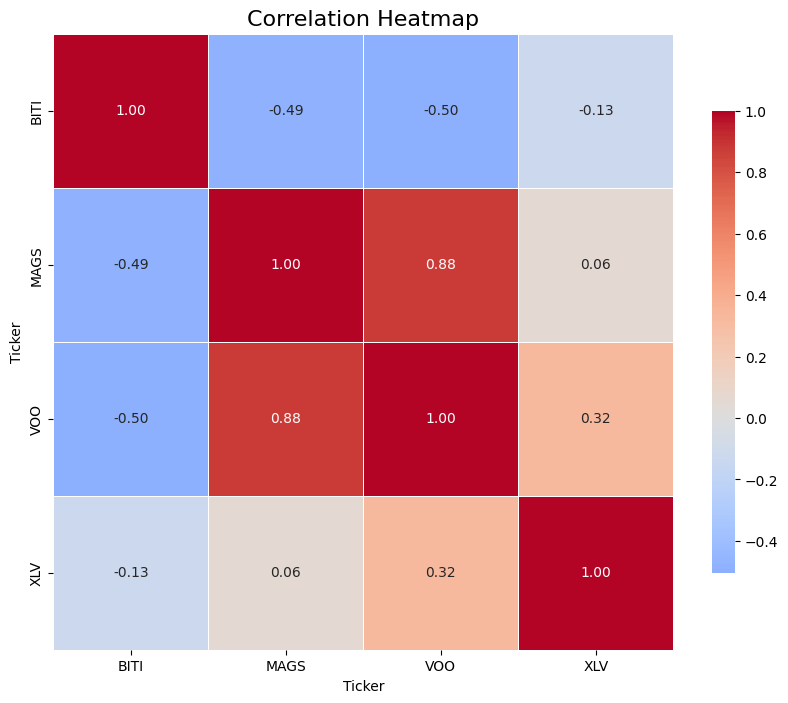

In [16]:

# Example usage
tickers = mrs_1m_df['ETF'].to_list()
ranked_picks = tickers


final_selection, corr_matrix = get_uncorrelated_picks(tickers, ranked_picks, threshold=0.66)

# Step 2: Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Step 3: Draw the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,         # Show correlation values
    fmt=".2f",          # Format to 2 decimal places
    cmap="coolwarm",    # Color map
    center=0,           # Center the colormap at 0
    linewidths=0.5,     # Lines between cells
    cbar_kws={"shrink": 0.75}  # Shrink color bar
)

# Step 4: Add title and show
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

In [17]:
final_selection

['BITI', 'XLV', 'MAGS']

In [18]:
# Function to compute ATR (Average True Range)
def compute_atr(df, period=10):
  try:
    df['High-Low'] = df['High'] - df['Low']
    df['High-Close'] = abs(df['High'] - df['Close'].shift(1))
    df['Low-Close'] = abs(df['Low'] - df['Close'].shift(1))
    df['TR'] = df[['High-Low', 'High-Close', 'Low-Close']].max(axis=1)
    return df['TR'].rolling(window=period).mean()
  except Exception as e:
      print("Something went wrong whilecomputing the ATR", e)


# Function to fetch daily data
def get_daily_data(ticker):
    df = yf.download(ticker, period="1y", interval="1d",auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)  # keep only first level
    df['20_day_SMA'] = df['Close'].rolling(window=20).mean()
    df['20_day_EMA'] = df['Close'].ewm(span=20, adjust=False).mean()
    df['50_day_avg_volume'] = df['Volume'].rolling(window=50).mean()
    df['8_day_EMA'] = df['Close'].ewm(span=8, adjust=False).mean()
    df['15_day_EMA'] = df['Close'].ewm(span=15, adjust=False).mean()
    df['21_day_EMA'] = df['Close'].ewm(span=21, adjust=False).mean()
    df['26_day_EMA'] = df['Close'].ewm(span=26, adjust=False).mean()
    df['50_day_SMA'] = df['Close'].rolling(window=50).mean()
    df['100_day_SMA'] = df['Close'].rolling(window=100).mean()
    df['200_day_SMA'] = df['Close'].rolling(window=200).mean()
    slope_50sma, _, _, _, _ = linregress(range(5), df["50_day_SMA"].tail(5))
    df['SMA_Slope_50'] = slope_50sma
    # Compute MACD using ta
    df["MACD_Line"] = ta.trend.macd(df["Close"], window_slow=26, window_fast=12)
    df["Signal_Line"] = ta.trend.macd_signal(df["Close"], window_slow=26, window_fast=12, window_sign=9)
    df["MACD_Hist"] = ta.trend.macd_diff(df["Close"], window_slow=26, window_fast=12, window_sign=9)
    df["MACD_Hist_above_zero"] = df["MACD_Hist"] > 0
    df["MACD_Hist_below_zero"] = df["MACD_Hist"] < 0
    df['macd_above_signal'] = df['MACD_Line'] > df['Signal_Line']
    df['macd_below_signal'] = df['MACD_Line'] < df['Signal_Line']
    # Add results to original DataFrame
    df['ATR'] =  compute_atr(df, 10)
    return df


def get_heikin_ashi_signal(ticker="AAPL", period="6mo", interval="1d"):
    # Fetch OHLC data
    df = yf.download(ticker, period=period, interval=interval, auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)  # keep only first level

    # Compute Heikin Ashi candles
    ha_df = pd.DataFrame(index=df.index)
    ha_df['HA_Close'] = (df['Open'] + df['High'] + df['Low'] + df['Close']) / 4

    ha_open = []
    for i in range(len(df)):
        if i == 0:
             ha_open.append((df['Open'].iloc[i] + df['Close'].iloc[i]) / 2)
        else:
            ha_open.append((ha_open[i-1] + ha_df['HA_Close'].iloc[i-1]) / 2)
    ha_df['HA_Open'] = ha_open
    ha_df['HA_High'] = ha_df[['HA_Open', 'HA_Close']].assign(High=df['High']).max(axis=1)
    ha_df['HA_Low'] = ha_df[['HA_Open', 'HA_Close']].assign(Low=df['Low']).min(axis=1)

    # Combine with original
    df = df.join(ha_df)
    # Check for green candle with flat bottom
    last = df.iloc[-1]
    green_candle = last['HA_Close'] > last['HA_Open']
    flat_bottom = abs(last['HA_Open'] - last['HA_Low']) < 0.01  # tiny wick or flat bottom tolerance
    signal = green_candle and flat_bottom

    print(f"\n🔍 Checking {ticker} ({interval} timeframe)")
    print(f"HA_Open: {last['HA_Open']:.2f}, HA_Close: {last['HA_Close']:.2f}, HA_Low: {last['HA_Low']:.2f}")
    if signal:
        print("✅ Heikin Ashi candle is GREEN with a FLAT bottom — strong bullish signal!")
    elif green_candle:
        print("🟢 Candle is green but not flat-bottomed — still bullish, but less strong.")
    else:
        print("🔴 Not a bullish candle — no entry confirmation yet.")

    return signal, green_candle


def anchored_vwap_old(ticker, anchor_date):
    """
    Calculate Anchored VWAP starting from a given anchor_date.
    Works with both single-level and multi-level columns (e.g. yfinance output).
    """
    # --- Step 1: Flatten columns if multi-index ---
    df = yf.download(ticker, period="1y", interval="1d",auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)  # keep only first level

    # --- Step 2: Ensure required columns exist ---
    required_cols = ["High", "Low", "Close", "Volume"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")

    # --- Step 3: Subset from anchor_date ---
    df_anchor = df.loc[df.index >= pd.to_datetime(anchor_date)].copy()
    if df_anchor.empty:
        raise ValueError(f"No data found on/after {anchor_date}")

    # --- Step 4: Compute typical price ---
    df_anchor["typical_price"] = (df_anchor["High"] + df_anchor["Low"] + df_anchor["Close"]) / 3.0

    # --- Step 5: Cumulative PV and VWAP ---
    df_anchor["cum_pv"] = (df_anchor["typical_price"].astype(float) * df_anchor["Volume"].astype(float)).cumsum()
    df_anchor["cum_vol"] = df_anchor["Volume"].astype(float).cumsum()
    df_anchor["anchored_vwap"] = df_anchor["cum_pv"] / df_anchor["cum_vol"]

    return df_anchor[["anchored_vwap"]]

In [19]:
today = datetime.today()
start_of_year = today.replace(month=1, day=1)

# First day of this month
first_day_month = today.replace(day=1)

# First day of this week (Monday as weekday 0)
first_day_week = today - timedelta(days=today.weekday())
print("First day of year:", start_of_year)

print("\nFirst day of this month:", first_day_month)
print("\nFirst day of this week:", first_day_week)

def most_recent_quarter_start(today=None):
    if today is None:
        today = pd.Timestamp.today().normalize()
    year = today.year
    month = today.month

    # Determine quarter start months: Jan, Apr, Jul, Oct
    if month >= 10:
        q_start = pd.Timestamp(year, 10, 1)
    elif month >= 7:
        q_start = pd.Timestamp(year, 7, 1)
    elif month >= 4:
        q_start = pd.Timestamp(year, 4, 1)
    else:
        q_start = pd.Timestamp(year, 1, 1)

    return q_start

# Example usage
print("Today:", pd.Timestamp.today().normalize())
print("Most recent quarter start:", most_recent_quarter_start())


First day of year: 2025-01-01 17:39:08.201670

First day of this month: 2025-11-01 17:39:08.201670

First day of this week: 2025-11-24 17:39:08.201670
Today: 2025-11-25 00:00:00
Most recent quarter start: 2025-10-01 00:00:00


In [21]:
results = []


for etf in mrs_1m_df['ETF'].to_list():
   df          = get_daily_data(etf)
   price       = df['Close'].iloc[-1]
   trail       = df['ATR'].iloc[-1]
   sma_50      = df['50_day_SMA'].iloc[-1]
   above_50sma = price  > df['50_day_SMA'].iloc[-1]
   sma_slope_50 = df['SMA_Slope_50'].iloc[-1]> 0
   vwap_sy     = anchored_vwap_old(etf, start_of_year)
   ytd_vwap    = vwap_sy['anchored_vwap'].iloc[-1]
   # MTD
   vwap_mtd     = anchored_vwap_old(etf, first_day_month)
   mtd_vwap    = vwap_mtd['anchored_vwap'].iloc[-1]
   # WTD
   #vwap_wtd     = anchored_vwap_old(etf, first_day_week )
   #wtd_vwap    = vwap_wtd['anchored_vwap'].iloc[-1]

   # QTD
   vwap_qtd     = anchored_vwap_old(etf, most_recent_quarter_start() )
   qtd_vwap    = vwap_qtd['anchored_vwap'].iloc[-1]

   print("Year to date VWAP is :", ytd_vwap)
   above_ytd_vwap = price > ytd_vwap
   HA_buy_signal,gc = get_heikin_ashi_signal(etf, period="90d", interval="1d")

   if  (above_50sma and sma_slope_50) and qtd_vwap and (HA_buy_signal or gc):
    trail = trail
    sma_50l = sma_50
    support_level = (qtd_vwap + sma_50 + qtd_vwap + mtd_vwap)/4
    entry_price  = price
    risk = np.abs(entry_price- support_level)
    resistance_level = entry_price + (2 *risk)
    reward = resistance_level - entry_price
    risk_reward_ratio = reward / risk
    # Ensure risk is greater than zero before division
    if risk > 0:
        rr_ratio  = reward / risk
    else:
        rr_ratio = np.nan

    stop_loss_perc = ((support_level- entry_price)/entry_price )*100
    take_profit_perc = ((resistance_level- entry_price )/entry_price )*100
    # Fetch the Entry_Signal from buy_list
    entry_signal = 'Monthly ETF Sector Rotation'

    # Append results with Entry_Signal
    results.append({
            "ETF": etf,
            "ATR": trail,
            "Risk-Reward": rr_ratio,
            "Stop Out Price": support_level,
            "Target Price": resistance_level,
            "Current Price": entry_price,
            "Entry Price": entry_price,
            "sma_50": sma_50l,
            "Entry Signal": entry_signal,  # Add entry signal
            "stop_loss_perc": stop_loss_perc,
            "take_profit_perc": take_profit_perc,
            "MTD VWAP": mtd_vwap,
            #"WTD VWAP": wtd_vwap,
            "QTD VWAP": qtd_vwap,
            "YTD VWAP": ytd_vwap
        })

    time.sleep(2)  # Add a delay of 1 second between requests


# Sort ETFs by highest risk-to-reward ratio
try:
   df_result = pd.DataFrame(results).dropna().sort_values(by="Risk-Reward", ascending=False).reset_index(drop = True)
   pass
except Exception as e:
  print("No Asset to buy today, check back some other time!")
  df_result = pd.DataFrame({"ETF": ["No Asset available"]})

#df2 =  df_results.merge(advancing_sectors[["ETF"]], on='ETF', how='left')
df_result['timestamp'] = datetime.now()
#df2.head()
df_result

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Year to date VWAP is : 20.73212913857496

🔍 Checking BITI (1d timeframe)
HA_Open: 23.60, HA_Close: 23.51, HA_Low: 23.30
🔴 Not a bullish candle — no entry confirmation yet.


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Year to date VWAP is : 138.50246850429963

🔍 Checking XLV (1d timeframe)
HA_Open: 154.02, HA_Close: 157.21, HA_Low: 154.02
✅ Heikin Ashi candle is GREEN with a FLAT bottom — strong bullish signal!


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Year to date VWAP is : 55.94344765418452

🔍 Checking MAGS (1d timeframe)
HA_Open: 64.39, HA_Close: 65.50, HA_Low: 64.39
✅ Heikin Ashi candle is GREEN with a FLAT bottom — strong bullish signal!


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Year to date VWAP is : 556.6280347704023

🔍 Checking VOO (1d timeframe)
HA_Open: 609.72, HA_Close: 616.37, HA_Low: 609.72
✅ Heikin Ashi candle is GREEN with a FLAT bottom — strong bullish signal!


,ETF,ATR,Risk-Reward,Stop Out Price,Target Price,Current Price,Entry Price,sma_50,Entry Signal,stop_loss_perc,take_profit_perc,MTD VWAP,QTD VWAP,YTD VWAP,timestamp
0,XLV,2.404504,2.0,147.684063,180.401862,158.589996,158.589996,144.785291,Monthly ETF Sector Rotation,-6.876810,13.753620,150.753176,147.598893,138.502469,2025-11-25 17:42:47.233069
1,MAGS,1.889499,2.0,65.433040,66.608912,65.824997,65.824997,65.331700,Monthly ETF Sector Rotation,-0.595454,1.190908,65.345363,65.527547,55.943448,2025-11-25 17:42:47.233069
2,VOO,10.798993,2.0,616.205590,626.507399,619.639526,619.639526,615.530300,Monthly ETF Sector Rotation,-0.554183,1.108366,616.401929,616.445066,556.628035,2025-11-25 17:42:47.233069
